In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# DEPENDENCIAS (ejecutar solo en Google Colab)
# ============================================================================
# En local: pip install -r requirements.txt
# En Colab: esta celda instala las librerías necesarias para TFT.
import sys
if 'google.colab' in sys.modules:
    import subprocess
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'pytorch-forecasting>=1.1.0', 'lightning>=2.0'],
        check=True
    )
    print('Dependencias TFT instaladas.')
else:
    try:
        import pytorch_forecasting
        print(f'pytorch-forecasting {pytorch_forecasting.__version__} OK.')
    except ImportError:
        print('AVISO: pytorch-forecasting no encontrado.\n'
              'Instalar con: pip install "pytorch-forecasting>=1.1.0" "lightning>=2.0"')

Dependencias TFT instaladas.


In [3]:
# ============================================================================
# KEEP-ALIVE COLAB — Evita desconexión por inactividad durante entrenamientos largos
# Ejecutar esta celda UNA VEZ antes del entrenamiento (solo tiene efecto en Colab)
# ============================================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from IPython.display import display, Javascript
    display(Javascript("""
    function ClickConnect(){
        console.log("Keep-alive: click en 'Conectar'");
        document.querySelector("colab-toolbar-button#connect")?.click();
    }
    var interval = setInterval(ClickConnect, 60000);
    console.log("Keep-alive iniciado (interval id=" + interval + ")");
    """))
    print("✓ Keep-alive activado (click automático cada 60 s)")
else:
    print("Entorno local — keep-alive no necesario")

<IPython.core.display.Javascript object>

✓ Keep-alive activado (click automático cada 60 s)


In [4]:
# ============================================================================
# EXPERIMENTO 2: TRANSFERENCIA TFT ENTRE PLANTAS SOLARES
# Pre-entrenamiento sobre 5 plantas fuente → Zero-shot + Fine-tuning en TALASOL
# ============================================================================
#
# Diferencia clave respecto al Exp2 N-BEATS:
# - TFT usa TimeSeriesDataSet de pytorch-forecasting (no DataLoaders PyTorch).
# - La transferencia usa state_dict: se crea un nuevo TFT desde los datos de
#   TALASOL (misma arquitectura) y se cargan los pesos pre-entrenados.
# - EncoderNormalizer (en lugar de GroupNormalizer) habilita zero-shot:
#   normaliza por ventana de encoder, sin estadísticas por grupo.
#
# En Google Colab: monta Drive y ejecuta os.chdir() ANTES de esta celda.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')

import sys
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from pathlib import Path

# pytorch-forecasting
from pytorch_forecasting import TemporalFusionTransformer

# Módulos del proyecto
from evaluation import ForecastEvaluator

# Módulos del experimento 2 — TFT
from ex2_transfer.ex2_tft_config import (
    PLANTAS_SOURCE, PLANTA_TARGET,
    SMOKE_TEST, SMOKE_MAX_ROWS,
    DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR,
    DEVICE, MAX_ENCODER_LENGTH,
    TIME_VARYING_KNOWN_REALS, TIME_VARYING_UNKNOWN_REALS, STATIC_REALS,
    MODEL_CFG, FINETUNE_CFG, FINETUNE_SIZES,
)
from ex2_transfer.tft_transfer import (
    encode_features,
    prepare_tft_df,
    build_source_datasets,
    build_target_datasets,
    get_tft_predictions,
    evaluate_tft,
    save_results_row,
    TFTTransferTrainer,
)
from ex1_compare.visualization import (
    plot_diagnostic, plot_timeseries, plot_learning_curves,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 80)
print('EXPERIMENTO 2: TRANSFERENCIA TFT')
print(f'Plantas fuente  : {PLANTAS_SOURCE}')
print(f'Planta destino  : {PLANTA_TARGET}')
print(f'Device          : {DEVICE}')
print(f'Smoke test      : {SMOKE_TEST}')
print(f'MAX_ENCODER_LEN : {MAX_ENCODER_LENGTH}h')
print(f'MODEL_CFG       : {MODEL_CFG}')
print(f'FINETUNE_CFG    : {FINETUNE_CFG}')
print(f'FINETUNE_SIZES  : {list(FINETUNE_SIZES.keys())}')
print('=' * 80)

[ex2_tft] Entorno: Google Colab | Device: cuda (Tesla T4)
[ex1] Entorno: Google Colab | Device: cuda (Tesla T4)
EXPERIMENTO 2: TRANSFERENCIA TFT
Plantas fuente  : ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA']
Planta destino  : TALASOL
Device          : cuda
Smoke test      : False
MAX_ENCODER_LEN : 48h
MODEL_CFG       : {'hidden_size': 64, 'attention_head_size': 4, 'dropout': 0.1, 'hidden_continuous_size': 16, 'lr': 0.001, 'batch_size': 64, 'max_epochs': 30, 'patience': 7}
FINETUNE_CFG    : {'max_epochs': 20, 'patience': 5, 'lr_factor': 0.3}
FINETUNE_SIZES  : ['zero_shot', '1_semana', '1_mes', '3_meses']


In [5]:
# ============================================================================
# 1. CARGA DE DATOS Y CODIFICACIÓN DE FEATURES
# ============================================================================

print('[1/7] Cargando y preparando datos...')

df_train_raw = pd.read_csv(DATA_DIR / 'train.csv')
df_val_raw   = pd.read_csv(DATA_DIR / 'val.csv')
df_test_raw  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'  Train: {len(df_train_raw):,} registros')
print(f'  Val:   {len(df_val_raw):,} registros')
print(f'  Test:  {len(df_test_raw):,} registros')
print(f'  Plantas: {sorted(df_train_raw["planta_nombre"].unique())}')

# Excluir filas con valid_data=False (curtailment o huecos > 6h) de train y val.
# Test NO se filtra: TFT necesita continuidad temporal para el encoder.
# Las predicciones sobre horas inválidas se filtran en la evaluación de métricas.
_HAS_VALID = 'valid_data' in df_train_raw.columns
if _HAS_VALID:
    n_tr_antes = len(df_train_raw)
    n_va_antes = len(df_val_raw)
    df_train_raw = df_train_raw[df_train_raw['valid_data'].fillna(True).astype(bool)].reset_index(drop=True)
    df_val_raw   = df_val_raw[df_val_raw['valid_data'].fillna(True).astype(bool)].reset_index(drop=True)
    print(f'  valid_data: train {n_tr_antes:,}→{len(df_train_raw):,} | '
          f'val {n_va_antes:,}→{len(df_val_raw):,} filas')

# Codificación de variables categóricas (misma que 05_baseline_tft.ipynb)
df_train = encode_features(df_train_raw)
df_val   = encode_features(df_val_raw)
df_test  = encode_features(df_test_raw)

# Verificar que todas las plantas necesarias están presentes
todas   = PLANTAS_SOURCE + [PLANTA_TARGET]
plantas = set(df_train['planta_nombre'].unique())
for p in todas:
    if p not in plantas:
        raise ValueError(f'Planta {p!r} no encontrada en train.csv')

# Verificar features requeridas
todas_features = (TIME_VARYING_KNOWN_REALS + TIME_VARYING_UNKNOWN_REALS
                  + STATIC_REALS + ['produccion'])
missing = set(todas_features) - set(df_train.columns)
if missing:
    raise ValueError(f'Columnas faltantes en train.csv: {missing}')

# Shapes con el límite de smoke test aplicado (igual que en el experimento real)
smoke_label = f' [smoke test, primeras {SMOKE_MAX_ROWS} filas]' if SMOKE_TEST else ''
print(f'\nShapes por planta (train){smoke_label}:')
for p in todas:
    df_p = prepare_tft_df(df_train, p, SMOKE_TEST, SMOKE_MAX_ROWS)
    print(f'  {p}: {len(df_p):,} filas')

print(f'\nFeatures TFT:')
print(f'  Known reals   : {TIME_VARYING_KNOWN_REALS}')
print(f'  Unknown reals : {TIME_VARYING_UNKNOWN_REALS}')
print(f'  Static reals  : {STATIC_REALS}')
print('\n[1/7] OK')

[1/7] Cargando y preparando datos...
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  Plantas: ['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
  valid_data: train 50,917→50,663 | val 6,780→6,755 filas

Shapes por planta (train):
  UPGARNACHA: 6,042 filas
  FVARENA: 8,948 filas
  NBALBOA: 8,906 filas
  RODRI: 8,956 filas
  UFMULA: 8,971 filas
  TALASOL: 8,840 filas

Features TFT:
  Known reals   : ['hora', 'mes', 'elevacion_solar', 'es_dia', 'estacion_encoded']
  Unknown reals : ['shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'temperature_2m']
  Static reals  : ['instalada_mw', 'zona_climatica_encoded', 'seguimiento_encoded']

[1/7] OK


In [6]:
# ============================================================================
# 2. PRE-ENTRENAMIENTO MULTI-PLANTA (plantas fuente)
# ============================================================================
import time

print('[2/7] Pre-entrenamiento TFT multi-planta...')
print('=' * 80)

ckpt_pretrained_path = CHECKPOINTS_DIR / 'pretrained.ckpt'

# ── RESUME: si ya existe el checkpoint Lightning, cargar y saltar ─────────────
_resumed = False
if ckpt_pretrained_path.exists():
    try:
        print(f'  ✓ Checkpoint pretrained.ckpt encontrado — skip pretraining')
        transfer_trainer = TFTTransferTrainer(
            model_cfg       = MODEL_CFG,
            device          = DEVICE,
            checkpoints_dir = CHECKPOINTS_DIR,
        )
        ckpt_data = torch.load(str(ckpt_pretrained_path), map_location='cpu', weights_only=False)
        transfer_trainer._pretrain_state = ckpt_data['state_dict']
        pretrain_hist   = {'train': [], 'val': []}
        pretrain_time_s = 0.0
        print(f'  Pesos cargados: {len(transfer_trainer._pretrain_state)} tensores')
        print('[2/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        ckpt_pretrained_path.unlink(missing_ok=True)
if not _resumed:
    # DataLoaders multi-planta
    print('\nConstruyendo TimeSeriesDataSets de plantas fuente:')
    source_train_ds, source_val_ds = build_source_datasets(
        plantas_source     = PLANTAS_SOURCE,
        df_train           = df_train,
        df_val             = df_val,
        known_reals        = TIME_VARYING_KNOWN_REALS,
        unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
        static_reals       = STATIC_REALS,
        max_encoder_length = MAX_ENCODER_LENGTH,
        smoke_test         = SMOKE_TEST,
        max_rows           = SMOKE_MAX_ROWS,
    )

    # Crear trainer
    transfer_trainer = TFTTransferTrainer(
        model_cfg       = MODEL_CFG,
        device          = DEVICE,
        checkpoints_dir = CHECKPOINTS_DIR,
    )

    print(f'\nPre-entrenando {MODEL_CFG["max_epochs"]} épocas '
          f'(patience={MODEL_CFG["patience"]})...')
    t0 = time.time()
    pretrain_hist = transfer_trainer.pretrain(
        train_ds = source_train_ds,
        val_ds   = source_val_ds,
        cfg      = MODEL_CFG,
    )
    pretrain_time_s = time.time() - t0
    print(f'  Tiempo pretraining: {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')
    print(f'  ✓ Checkpoint guardado: {ckpt_pretrained_path}')

    # Curvas de aprendizaje del pretraining
    plot_learning_curves(
        [pretrain_hist], PLANTA_TARGET, 'tft-pretrain',
        save_dir=RESULTS_DIR / 'figures',
    )
    print('\n[2/7] OK')

[2/7] Pre-entrenamiento TFT multi-planta...
  ✓ Checkpoint pretrained.ckpt encontrado — skip pretraining
  Pesos cargados: 477 tensores
[2/7] OK (desde checkpoint)


[3/7] Zero-shot en TALASOL...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  TALASOL: zero-shot (sin fine-tuning)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]
  State dict transferido: 0 keys sin cargar, 0 ignoradas


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=zero_shot  MAE=30.8913  RMSE=64.0966  R2=0.8893

Zero-shot → MAE=30.89  RMSE=64.10  MAPE=150.33%  R2=0.8893
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_diagnostic.png


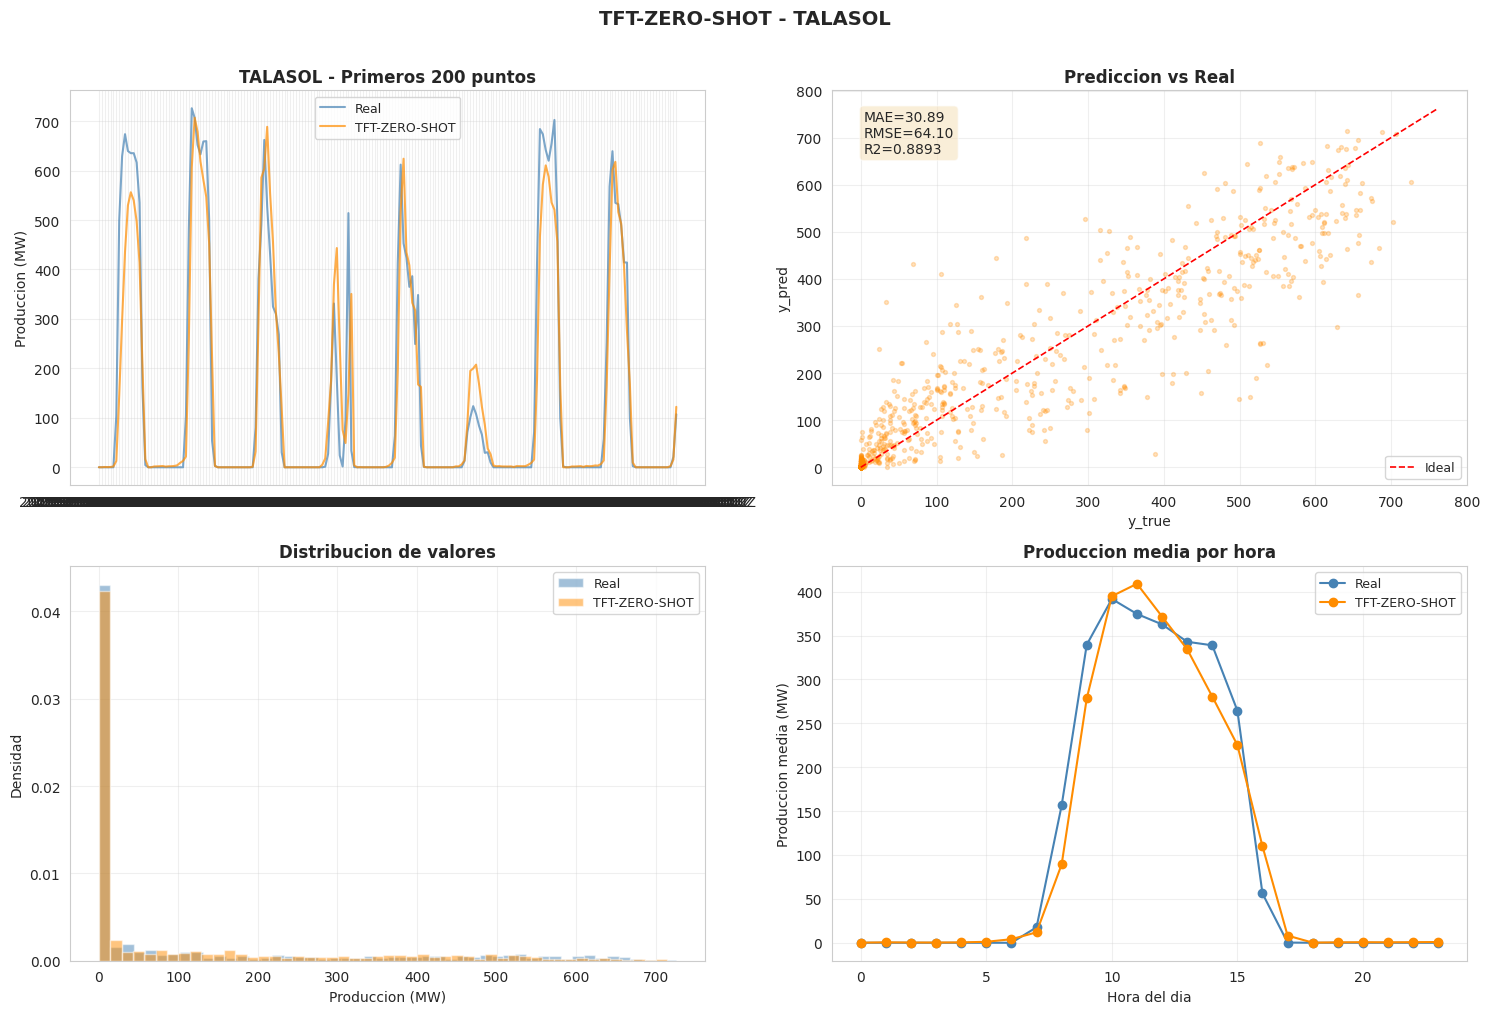

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_timeseries.png


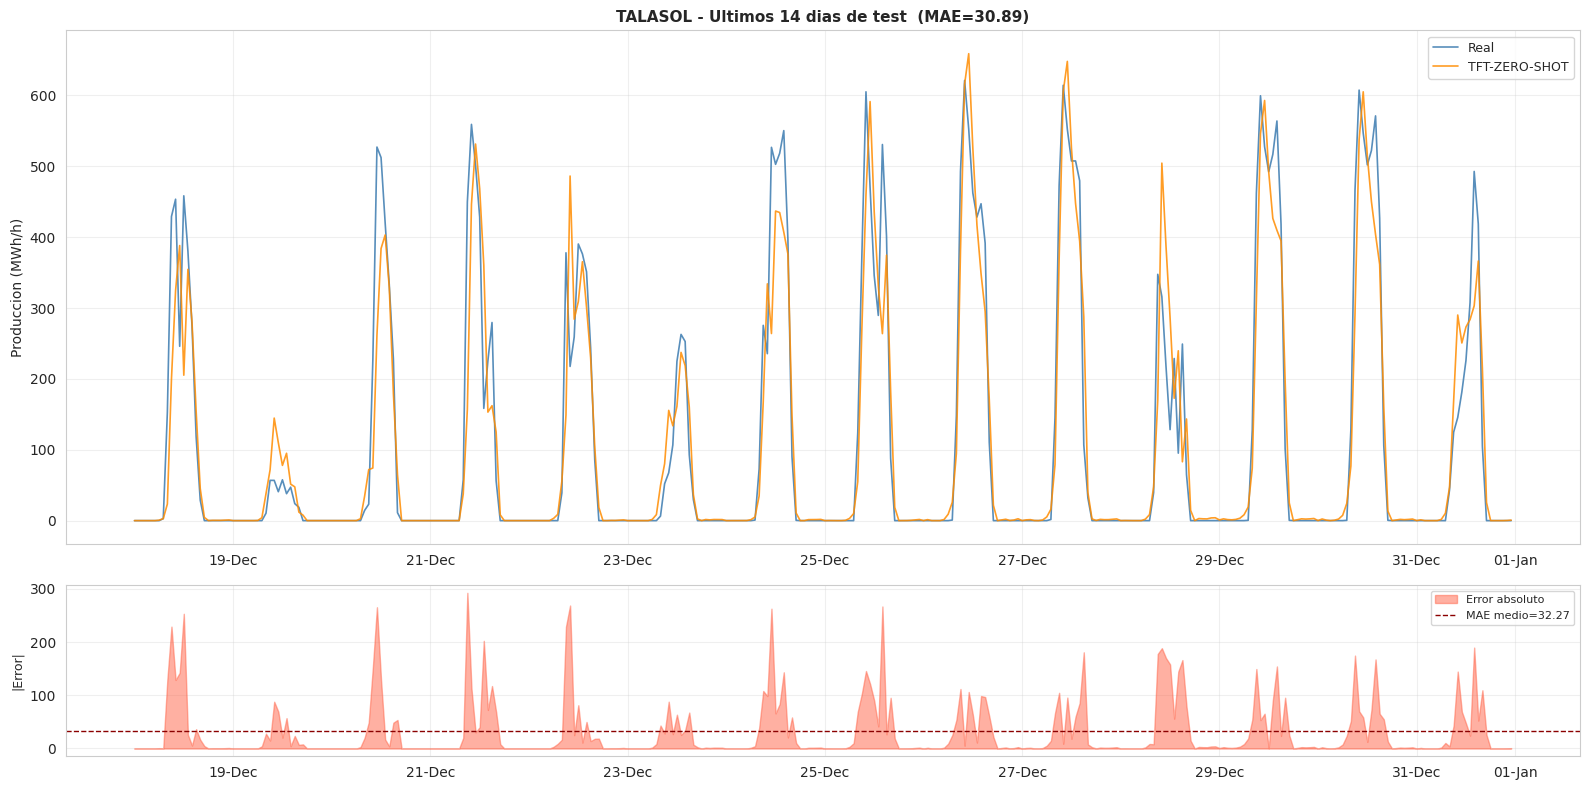


[3/7] OK


In [7]:
# ============================================================================
# 3. EVALUACIÓN ZERO-SHOT EN TALASOL
# ============================================================================

print('[3/7] Zero-shot en TALASOL...')
print('=' * 80)

preds_zs_csv = CHECKPOINTS_DIR / 'preds_zero_shot.csv'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_zs_csv.exists():
    try:
        print(f'  ✓ Predicciones zero-shot encontradas — skip inferencia')
        df_pred_zs = pd.read_csv(preds_zs_csv)
        if 'timestamp' in df_pred_zs.columns:
            df_pred_zs['timestamp'] = pd.to_datetime(df_pred_zs['timestamp'])
        print('[3/7] OK (desde CSV)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_zs_csv.unlink(missing_ok=True)
if not _resumed:
    _, val_ds_zs, test_ds_zs = build_target_datasets(
        planta_target      = PLANTA_TARGET,
        df_train           = df_train,
        df_val             = df_val,
        df_test            = df_test,
        known_reals        = TIME_VARYING_KNOWN_REALS,
        unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
        static_reals       = STATIC_REALS,
        max_encoder_length = MAX_ENCODER_LENGTH,
        n_finetune_hours   = 0,
        smoke_test         = SMOKE_TEST,
        max_rows           = SMOKE_MAX_ROWS,
    )

    model_zs = transfer_trainer._build_tft(test_ds_zs, lr=MODEL_CFG['lr'])

    missing, unexpected = model_zs.load_state_dict(
        transfer_trainer._pretrain_state, strict=False
    )
    print(f'  State dict transferido: {len(missing)} keys sin cargar, '
          f'{len(unexpected)} ignoradas')

    metrics_zs, df_pred_zs = evaluate_tft(
        model_zs, test_ds_zs, df_test_raw, PLANTA_TARGET,
        batch_size=MODEL_CFG['batch_size']
    )
    metrics_zs['training_time_s'] = 0.0
    save_results_row(RESULTS_DIR, 'zero_shot', metrics_zs, n_ft_hours=0)

    print(f"\nZero-shot → MAE={metrics_zs['MAE']:.2f}  "
          f"RMSE={metrics_zs['RMSE']:.2f}  "
          f"MAPE={metrics_zs['MAPE']:.2f}%  "
          f"R2={metrics_zs['R2']:.4f}")

    df_pred_zs.to_csv(preds_zs_csv, index=False)

    plot_diagnostic(df_pred_zs, PLANTA_TARGET, 'tft-zero-shot',
                    save_dir=RESULTS_DIR / 'figures')
    plot_timeseries(df_pred_zs, PLANTA_TARGET, 'tft-zero-shot',
                    save_dir=RESULTS_DIR / 'figures', days=14)
    print('\n[3/7] OK')

In [8]:
# ============================================================================
# 4. FINE-TUNING PROGRESIVO EN TALASOL
# ============================================================================

print('[4/7] Fine-tuning progresivo...')
print('=' * 80)

ft_scenarios = {k: v for k, v in FINETUNE_SIZES.items() if v > 0}

ft_histories = {}
ft_preds     = {}
ft_times     = {}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME: si ya existen predicciones guardadas, cargar y saltar ─────────
    preds_csv = CHECKPOINTS_DIR / f'preds_ft_{scenario_name}.csv'
    if preds_csv.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_preds[scenario_name]     = df_tmp
            ft_times[scenario_name]     = 0.0
            ft_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv.unlink(missing_ok=True)

    ft_ds, val_ds_ft, test_ds_ft = build_target_datasets(
        planta_target      = PLANTA_TARGET,
        df_train           = df_train,
        df_val             = df_val,
        df_test            = df_test,
        known_reals        = TIME_VARYING_KNOWN_REALS,
        unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
        static_reals       = STATIC_REALS,
        max_encoder_length = MAX_ENCODER_LENGTH,
        n_finetune_hours   = n_hours,
        smoke_test         = SMOKE_TEST,
        max_rows           = SMOKE_MAX_ROWS,
    )

    if ft_ds is None:
        print(f'  ⚠ Datos insuficientes — saltando {scenario_name}')
        continue

    ft_cfg = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr']}

    t0 = time.time()
    model_ft, ft_hist = transfer_trainer.finetune(
        ft_ds         = ft_ds,
        val_ds        = val_ds_ft,
        cfg           = ft_cfg,
        freeze_temporal = False,
        scenario_name = f'ft_{scenario_name}',
    )
    ft_times[scenario_name] = time.time() - t0
    ft_histories[scenario_name] = ft_hist
    print(f'  Tiempo FT: {ft_times[scenario_name]/60:.1f} min ({ft_times[scenario_name]:.0f} s)')

    # Evaluación
    metrics_ft, df_pred_ft = evaluate_tft(
        model_ft, test_ds_ft, df_test_raw, PLANTA_TARGET,
        batch_size=MODEL_CFG['batch_size']
    )
    metrics_ft['training_time_s'] = ft_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_{scenario_name}', metrics_ft, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_ft['MAE']:.2f}  RMSE={metrics_ft['RMSE']:.2f}  "
          f"MAPE={metrics_ft['MAPE']:.2f}%  R2={metrics_ft['R2']:.4f}")

    # Guardar predicciones
    df_pred_ft.to_csv(preds_csv, index=False)
    ft_preds[scenario_name] = df_pred_ft
    print(f'  ✓ Predicciones guardadas → {preds_csv.name}')

print('\n[4/7] OK')

[4/7] Fine-tuning progresivo...

--- Fine-tuning: 1_semana (168 horas) ---
  TALASOL fine-tune: 168 seqs (216 filas)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

✓ Fine-tuning completado | best val_loss: 33.8227
  Tiempo FT: 0.4 min (25 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=ft_1_semana  MAE=30.8271  RMSE=63.4372  R2=0.8915
  → MAE=30.83  RMSE=63.44  MAPE=170.86%  R2=0.8915
  ✓ Predicciones guardadas → preds_ft_1_semana.csv

--- Fine-tuning: 1_mes (720 horas) ---


...

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  TALASOL fine-tune: 2,160 seqs (2208 filas)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

✓ Fine-tuning completado | best val_loss: 25.5124
  Tiempo FT: 1.4 min (84 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=ft_3_meses  MAE=25.6961  RMSE=59.3938  R2=0.9049
  → MAE=25.70  RMSE=59.39  MAPE=94.58%  R2=0.9049
  ✓ Predicciones guardadas → preds_ft_3_meses.csv

[4/7] OK


In [9]:
# ============================================================================
# 4b. FINE-TUNING CON LAYER FREEZING (LSTM + attention congelados)
# ============================================================================

print('[4b/7] Fine-tuning con layer freezing...')
print('=' * 80)
print('Congelado: LSTM encoder + LSTM decoder + multihead attention')
print('Entrenable: variable selection, static context, output layers')

ft_frozen_histories = {}
ft_frozen_preds     = {}
ft_frozen_times     = {}

ft_cfg_frozen = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr'], 'lr_factor': 1.0}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning frozen: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME ────────────────────────────────────────────────────────────────
    preds_csv_frz = CHECKPOINTS_DIR / f'preds_ft_frozen_{scenario_name}.csv'
    if preds_csv_frz.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_frozen_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv_frz)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_frozen_preds[scenario_name]     = df_tmp
            ft_frozen_times[scenario_name]     = 0.0
            ft_frozen_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv_frz.unlink(missing_ok=True)

    ft_ds_frz, val_ds_frz, test_ds_frz = build_target_datasets(
        planta_target      = PLANTA_TARGET,
        df_train           = df_train,
        df_val             = df_val,
        df_test            = df_test,
        known_reals        = TIME_VARYING_KNOWN_REALS,
        unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
        static_reals       = STATIC_REALS,
        max_encoder_length = MAX_ENCODER_LENGTH,
        n_finetune_hours   = n_hours,
        smoke_test         = SMOKE_TEST,
        max_rows           = SMOKE_MAX_ROWS,
    )

    if ft_ds_frz is None:
        print(f'  ⚠ Datos insuficientes — saltando {scenario_name}')
        continue

    t0 = time.time()
    model_frz, frz_hist = transfer_trainer.finetune(
        ft_ds           = ft_ds_frz,
        val_ds          = val_ds_frz,
        cfg             = ft_cfg_frozen,
        freeze_temporal = True,
        scenario_name   = f'ft_frozen_{scenario_name}',
    )
    ft_frozen_times[scenario_name] = time.time() - t0
    ft_frozen_histories[scenario_name] = frz_hist
    print(f'  Tiempo FT frozen: {ft_frozen_times[scenario_name]/60:.1f} min '
          f'({ft_frozen_times[scenario_name]:.0f} s)')

    metrics_frz, df_pred_frz = evaluate_tft(
        model_frz, test_ds_frz, df_test_raw, PLANTA_TARGET,
        batch_size=MODEL_CFG['batch_size']
    )
    metrics_frz['training_time_s'] = ft_frozen_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_frozen_{scenario_name}',
                     metrics_frz, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_frz['MAE']:.2f}  RMSE={metrics_frz['RMSE']:.2f}  "
          f"MAPE={metrics_frz['MAPE']:.2f}%  R2={metrics_frz['R2']:.4f}")

    df_pred_frz.to_csv(preds_csv_frz, index=False)
    ft_frozen_preds[scenario_name] = df_pred_frz
    print(f'  ✓ Predicciones guardadas → {preds_csv_frz.name}')

print('\n[4b/7] OK')

[4b/7] Fine-tuning con layer freezing...
Congelado: LSTM encoder + LSTM decoder + multihead attention
Entrenable: variable selection, static context, output layers

--- Fine-tuning frozen: 1_semana (168 horas) ---


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  TALASOL fine-tune: 168 seqs (216 filas)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]
  [fine-tune] Congelado: LSTM encoder+decoder+attention | entrenables: 216,227/286,065


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

...

✓ Fine-tuning completado | best val_loss: 27.0845
  Tiempo FT frozen: 0.8 min (48 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=ft_frozen_1_mes  MAE=29.3175  RMSE=61.4605  R2=0.8982
  → MAE=29.32  RMSE=61.46  MAPE=130.11%  R2=0.8982
  ✓ Predicciones guardadas → preds_ft_frozen_1_mes.csv

--- Fine-tuning frozen: 3_meses (2160 horas) ---
  TALASOL fine-tune: 2,160 seqs (2208 filas)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]
  [fine-tune] Congelado: LSTM encoder+decoder+attention | entrenables: 216,227/286,065


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

✓ Fine-tuning completado | best val_loss: 25.3598
  Tiempo FT frozen: 1.5 min (88 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=ft_frozen_3_meses  MAE=25.7421  RMSE=59.5101  R2=0.9045
  → MAE=25.74  RMSE=59.51  MAPE=87.79%  R2=0.9045
  ✓ Predicciones guardadas → preds_ft_frozen_3_meses.csv

[4b/7] OK


In [10]:
# ============================================================================
# 5. BASELINE: TFT ENTRENADO DESDE CERO EN TALASOL
# ============================================================================

print('[5/7] Baseline (TFT entrenado desde cero en TALASOL)...')
print('=' * 80)

preds_bl_csv = CHECKPOINTS_DIR / 'preds_baseline.csv'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_bl_csv.exists():
    try:
        print(f'  ✓ Checkpoint baseline encontrado — skip')
        df_pred_bl = pd.read_csv(preds_bl_csv)
        if 'timestamp' in df_pred_bl.columns:
            df_pred_bl['timestamp'] = pd.to_datetime(df_pred_bl['timestamp'])
        baseline_hist   = {'train': [], 'val': []}
        baseline_time_s = 0.0
        print('[5/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_bl_csv.unlink(missing_ok=True)
if not _resumed:
    ft_ds_bl, val_ds_bl, test_ds_bl = build_target_datasets(
        planta_target      = PLANTA_TARGET,
        df_train           = df_train,
        df_val             = df_val,
        df_test            = df_test,
        known_reals        = TIME_VARYING_KNOWN_REALS,
        unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
        static_reals       = STATIC_REALS,
        max_encoder_length = MAX_ENCODER_LENGTH,
        n_finetune_hours   = None,
        smoke_test         = SMOKE_TEST,
        max_rows           = SMOKE_MAX_ROWS,
    )

    model_bl = transfer_trainer._build_tft(ft_ds_bl, lr=MODEL_CFG['lr'])

    print(f'\nEntrenando desde cero: {MODEL_CFG["max_epochs"]} épocas...')
    train_dl_bl = ft_ds_bl.to_dataloader(
        train=True,  batch_size=MODEL_CFG['batch_size'], num_workers=0, pin_memory=False
    )
    val_dl_bl = val_ds_bl.to_dataloader(
        train=False, batch_size=MODEL_CFG['batch_size'] * 2, num_workers=0, pin_memory=False
    )

    trainer_bl, loss_cb_bl, ckpt_cb_bl = transfer_trainer._build_pl_trainer(
        MODEL_CFG, 'baseline_scratch'
    )
    t0 = time.time()
    trainer_bl.fit(model_bl, train_dataloaders=train_dl_bl, val_dataloaders=val_dl_bl)
    baseline_time_s = time.time() - t0
    print(f'  Tiempo baseline: {baseline_time_s/60:.1f} min ({baseline_time_s:.0f} s)')

    model_bl = transfer_trainer._load_best_checkpoint(ckpt_cb_bl, model_bl)
    baseline_hist = transfer_trainer._build_hist(loss_cb_bl, len(ft_ds_bl), len(val_ds_bl))

    metrics_bl, df_pred_bl = evaluate_tft(
        model_bl, test_ds_bl, df_test_raw, PLANTA_TARGET,
        batch_size=MODEL_CFG['batch_size']
    )
    metrics_bl['training_time_s'] = baseline_time_s
    save_results_row(RESULTS_DIR, 'baseline', metrics_bl, n_ft_hours=0)

    print(f"\nBaseline → MAE={metrics_bl['MAE']:.2f}  "
          f"RMSE={metrics_bl['RMSE']:.2f}  "
          f"MAPE={metrics_bl['MAPE']:.2f}%  "
          f"R2={metrics_bl['R2']:.4f}")

    df_pred_bl.to_csv(preds_bl_csv, index=False)
    print(f'  ✓ Predicciones guardadas → {preds_bl_csv.name}')
    print('\n[5/7] OK')

[5/7] Baseline (TFT entrenado desde cero en TALASOL)...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  TALASOL baseline: 8,840 seqs (todo el train)
  val=1,057  test=1,439
  TFT: 286,065 parámetros  |  cuantiles: [0.5]

Entrenando desde cero: 30 épocas...


INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


  Tiempo baseline: 15.4 min (925 s)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/metrics.csv  | scenario=baseline  MAE=24.9984  RMSE=56.6238  R2=0.9136

Baseline → MAE=25.00  RMSE=56.62  MAPE=92.64%  R2=0.9136
  ✓ Predicciones guardadas → preds_baseline.csv

[5/7] OK


In [11]:
# ============================================================================
# 6. TABLA RESUMEN
# ============================================================================

print('[6/7] Tabla resumen...')

df_results = pd.read_csv(RESULTS_DIR / 'metrics.csv')

# Última ejecución de cada escenario
df_latest = (
    df_results
    .sort_values('timestamp')
    .groupby('scenario', as_index=False)
    .last()
)

# Orden lógico
scenario_order = [
    'zero_shot',
    'ft_1_semana',        'ft_frozen_1_semana',
    'ft_1_mes',           'ft_frozen_1_mes',
    'ft_3_meses',         'ft_frozen_3_meses',
    'baseline',
]
df_latest['_order'] = (
    df_latest['scenario']
    .map({s: i for i, s in enumerate(scenario_order)})
    .fillna(99)
)
df_latest = df_latest.sort_values('_order').drop(columns='_order')

# Mejoras relativas
zs_mae = df_latest.loc[df_latest['scenario'] == 'zero_shot', 'MAE'].values
bl_mae = df_latest.loc[df_latest['scenario'] == 'baseline',  'MAE'].values

if len(zs_mae) > 0:
    df_latest['mejora_vs_zeroshot_%'] = (
        (zs_mae[0] - df_latest['MAE']) / zs_mae[0] * 100
    ).round(2)
if len(bl_mae) > 0:
    df_latest['mejora_vs_baseline_%'] = (
        (bl_mae[0] - df_latest['MAE']) / bl_mae[0] * 100
    ).round(2)

cols_show = ['scenario', 'n_ft_hours', 'MAE', 'RMSE', 'MAPE', 'R2',
             'training_time_s', 'mejora_vs_zeroshot_%', 'mejora_vs_baseline_%']
cols_show = [c for c in cols_show if c in df_latest.columns]

print('\nRESUMEN EXPERIMENTO 2 — TFT Transfer Learning:')
print(df_latest[cols_show].to_string(index=False))
print(f'\n  Tiempo pretraining (multi-planta): {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')
if 'training_time_s' in df_latest.columns:
    print(f'  Tiempo total FT + baseline: {df_latest["training_time_s"].sum():.0f} s')

summary_path = RESULTS_DIR / 'summary.csv'
df_latest[cols_show].to_csv(summary_path, index=False)
print(f'\nTabla guardada: {summary_path}')

# ── Guardar predicciones por escenario para análisis económico (Exp 5) ────────
print('\nGuardando predicciones por escenario (Exp 5)...')
pred_rows = []

all_scenario_preds = {'zero_shot': df_pred_zs}
for k, df_p in ft_preds.items():
    all_scenario_preds[f'ft_{k}'] = df_p
for k, df_p in ft_frozen_preds.items():
    all_scenario_preds[f'ft_frozen_{k}'] = df_p
all_scenario_preds['baseline'] = df_pred_bl

for scenario, df_p in all_scenario_preds.items():
    if df_p is None or len(df_p) == 0:
        continue
    df_tmp = df_p[['timestamp', 'y_true', 'y_pred']].copy()
    df_tmp['scenario'] = scenario
    pred_rows.append(df_tmp)

if pred_rows:
    df_all_preds = pd.concat(pred_rows, ignore_index=True)
    preds_path = RESULTS_DIR / 'predictions_TALASOL.csv'
    df_all_preds.to_csv(preds_path, index=False)
    print(f'  Guardado: {preds_path}  '
          f'({len(df_all_preds)} filas, {df_all_preds["scenario"].nunique()} escenarios)')

print('\n[6/7] OK')


[6/7] Tabla resumen...

RESUMEN EXPERIMENTO 2 — TFT Transfer Learning:
          scenario  n_ft_hours     MAE    RMSE     MAPE     R2  training_time_s  mejora_vs_zeroshot_%  mejora_vs_baseline_%
         zero_shot           0 30.8913 64.0966 150.3335 0.8893           0.0000                0.0000              -23.5700
       ft_1_semana         168 30.8271 63.4372 170.8571 0.8915          25.1000                0.2100              -23.3200
ft_frozen_1_semana         168 33.9891 65.8615 243.9779 0.8831          19.2000              -10.0300              -35.9700
          ft_1_mes         720 27.4205 61.2946  90.7507 0.8987          97.3000               11.2400               -9.6900
   ft_frozen_1_mes         720 29.3175 61.4605 130.1114 0.8982          47.8000                5.0900              -17.2800
        ft_3_meses        2160 25.6961 59.3938  94.5753 0.9049          83.8000               16.8200               -2.7900
 ft_frozen_3_meses        2160 25.7421 59.5101  87.7858 0.904

[7/7] Visualización...


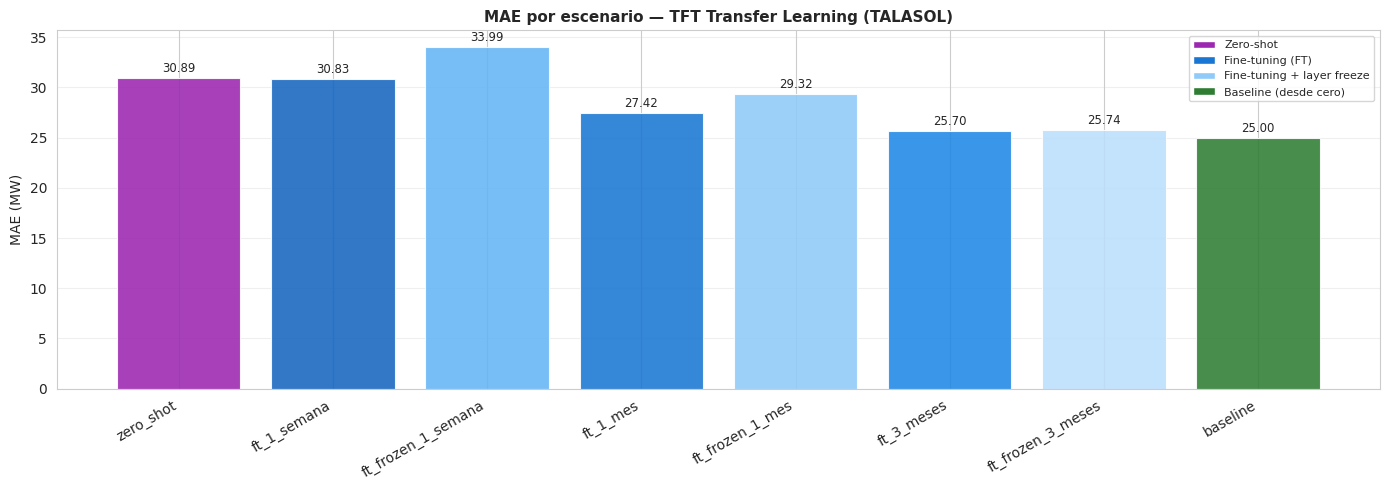

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/mae_by_scenario.png
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_timeseries.png


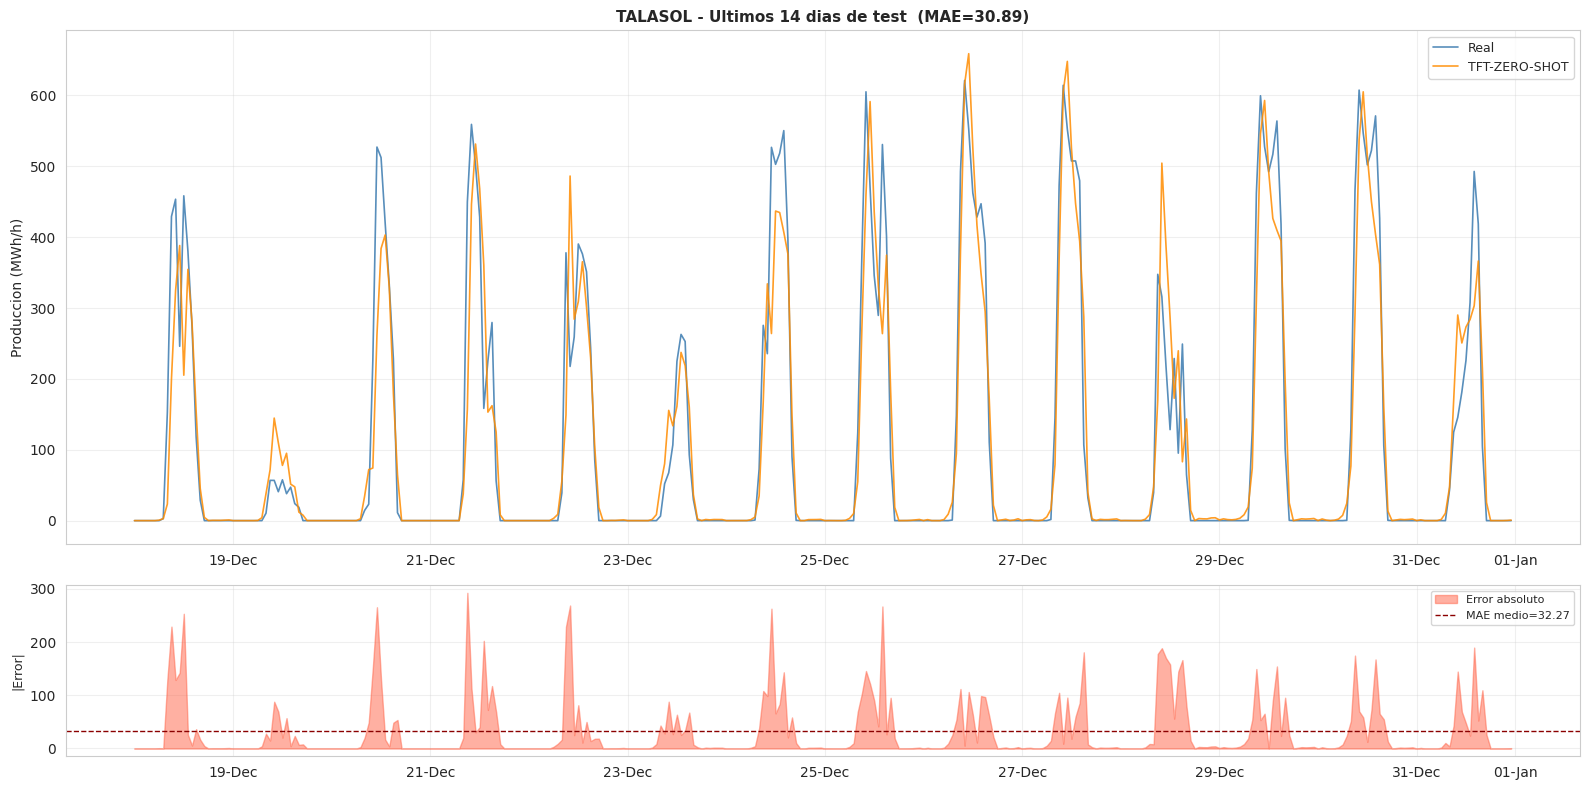

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_timeseries.png


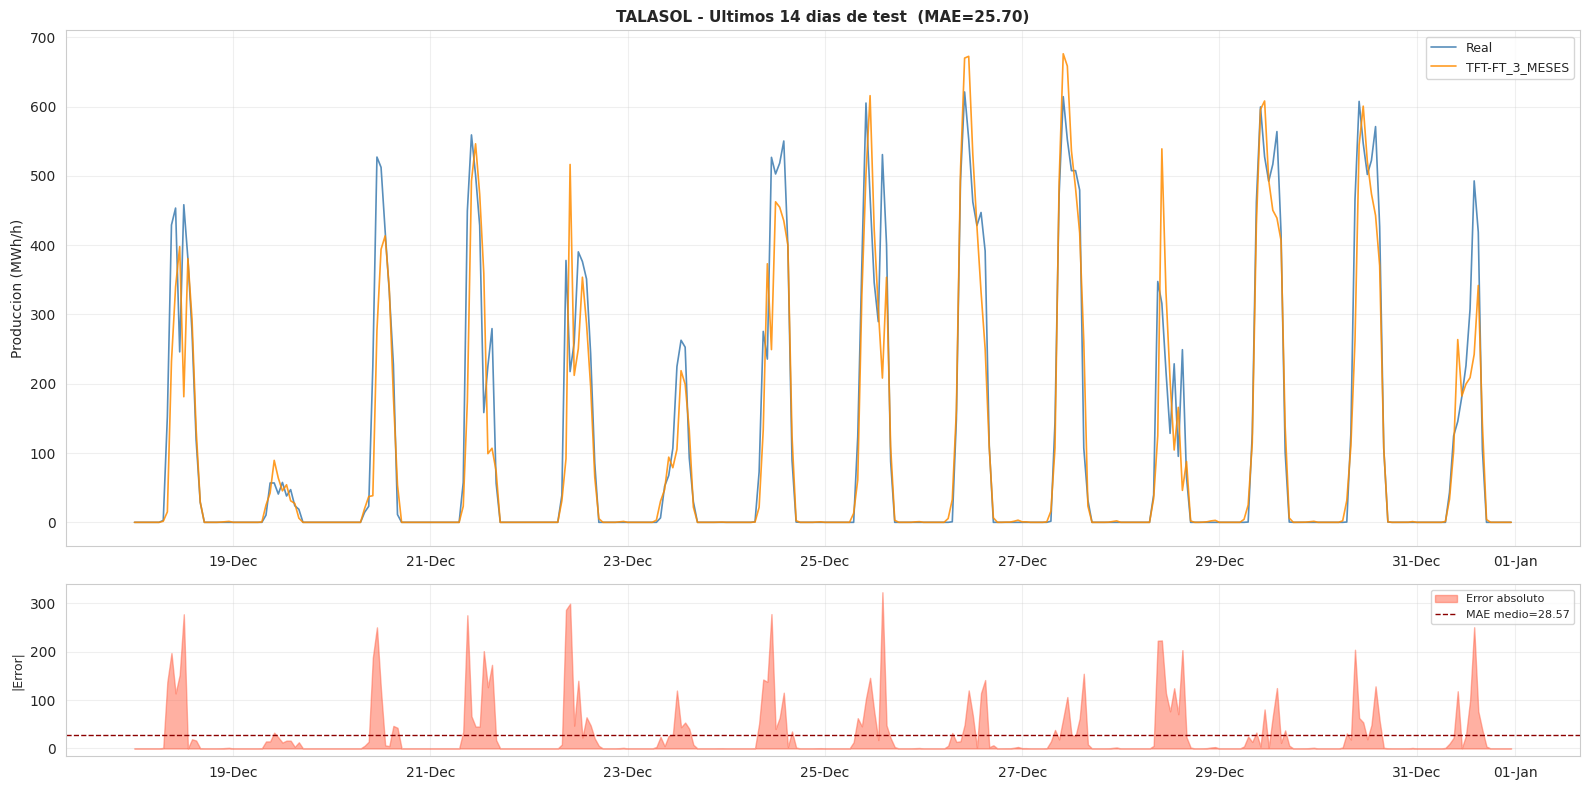

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_timeseries.png


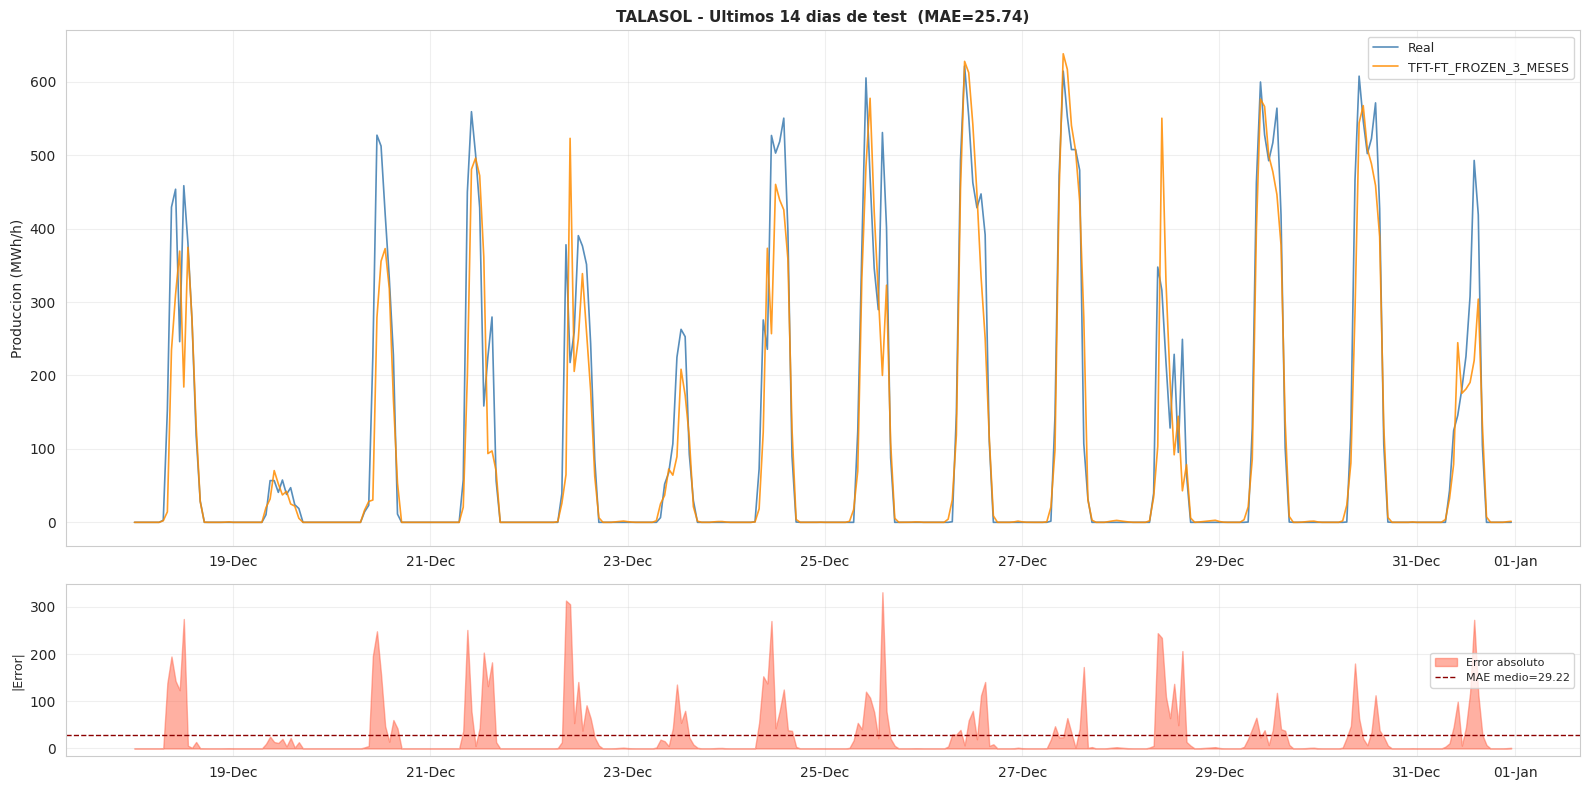

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_timeseries.png


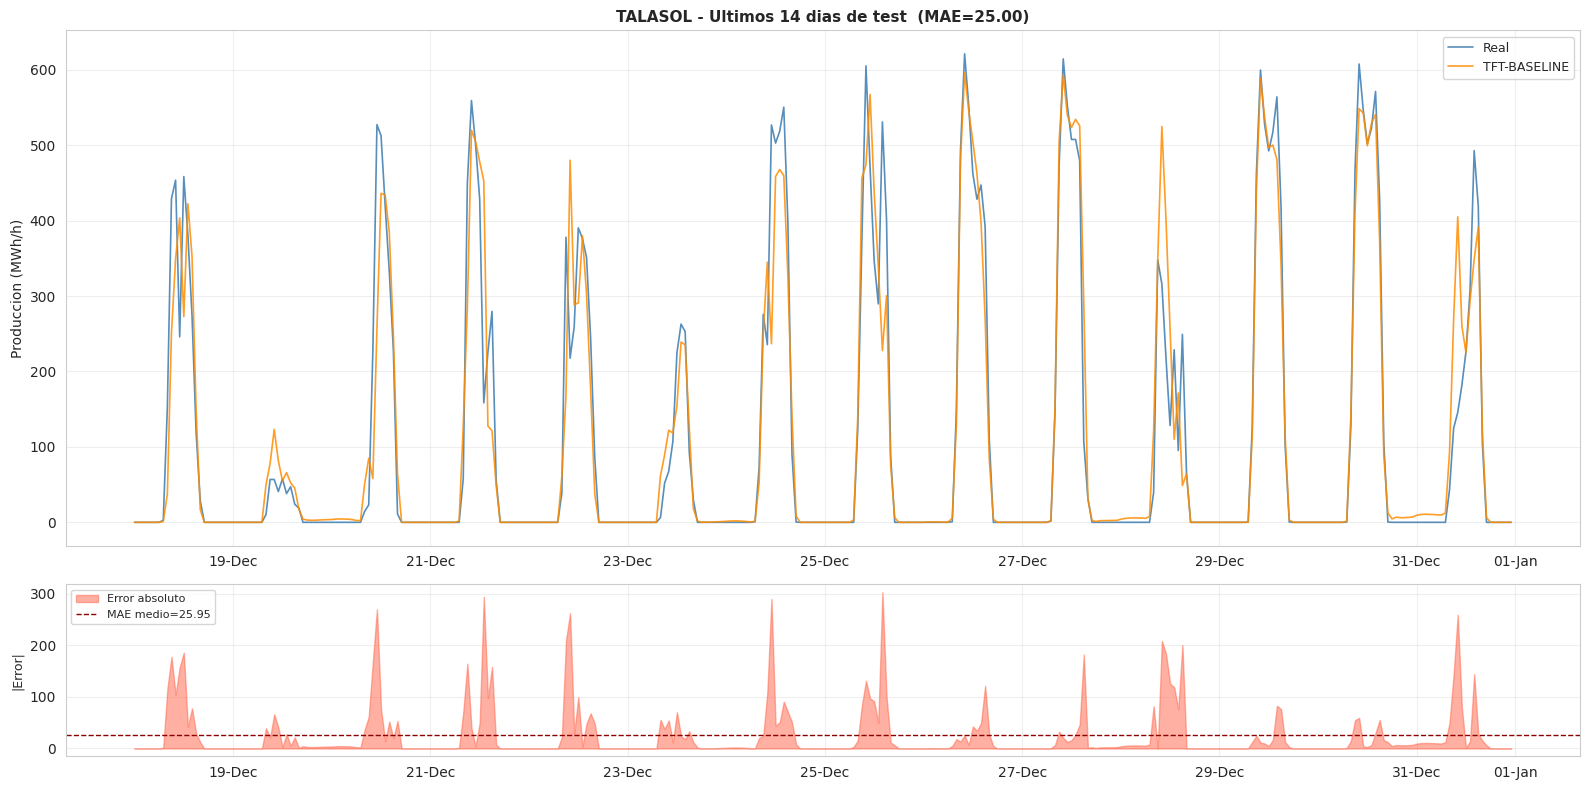

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures/TALASOL_learning_curves.png


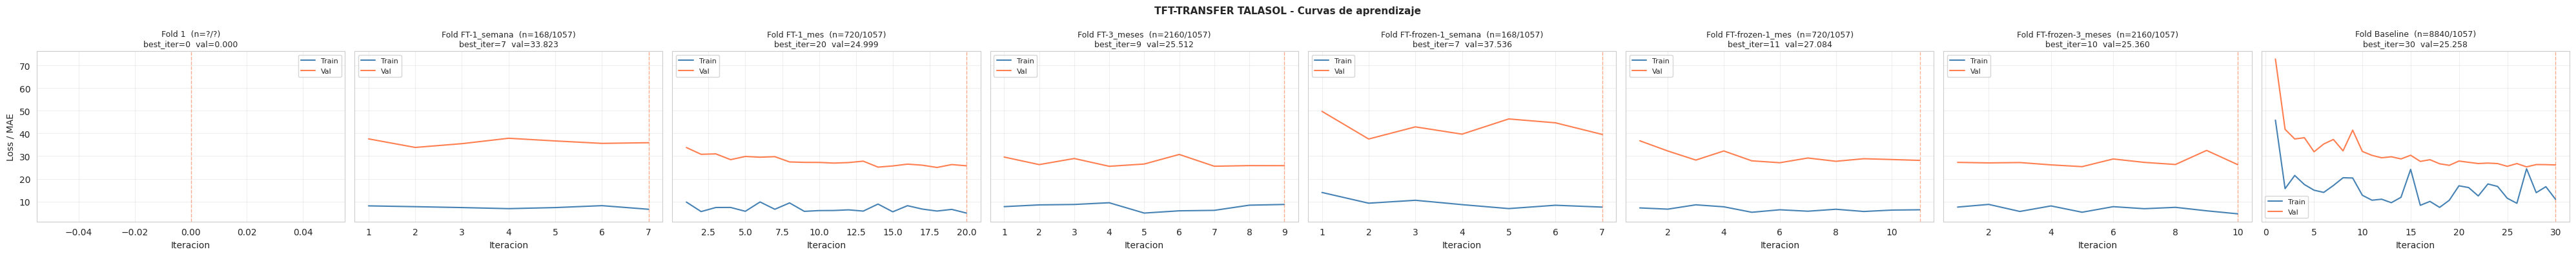


EXPERIMENTO 2 TFT COMPLETADO
  Resultados  : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft
  Figuras     : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/tft/figures
  Checkpoints : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex2_transfer/tft


In [12]:
# ============================================================================
# 7. VISUALIZACIÓN
# ============================================================================

print('[7/7] Visualización...')
fig_dir = RESULTS_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# ── 7a. Bar plot MAE por escenario ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

scenario_labels = df_latest['scenario'].tolist()
mae_vals        = df_latest['MAE'].tolist()

color_map = {
    'zero_shot':          '#9C27B0',
    'ft_1_semana':        '#1565C0',
    'ft_frozen_1_semana': '#64B5F6',
    'ft_1_mes':           '#1976D2',
    'ft_frozen_1_mes':    '#90CAF9',
    'ft_3_meses':         '#1E88E5',
    'ft_frozen_3_meses':  '#BBDEFB',
    'baseline':           '#2E7D32',
}
colors = [color_map.get(s, '#BDBDBD') for s in scenario_labels]

bars = ax.bar(scenario_labels, mae_vals, color=colors, alpha=0.88,
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('MAE (MW)', fontsize=10)
ax.set_title(f'MAE por escenario — TFT Transfer Learning ({PLANTA_TARGET})',
             fontsize=11, fontweight='bold')
ax.set_xticklabels(scenario_labels, rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    mpatches.Patch(facecolor='#9C27B0', label='Zero-shot'),
    mpatches.Patch(facecolor='#1976D2', label='Fine-tuning (FT)'),
    mpatches.Patch(facecolor='#90CAF9', label='Fine-tuning + layer freeze'),
    mpatches.Patch(facecolor='#2E7D32', label='Baseline (desde cero)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / 'mae_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {fig_dir}/mae_by_scenario.png')

# ── 7b. Series temporales ─────────────────────────────────────────────────────
# Zero-shot
plot_timeseries(df_pred_zs, PLANTA_TARGET, 'tft-zero-shot',
                save_dir=fig_dir, days=14)

# Mejor FT normal (más datos)
if ft_preds:
    best_ft = max(ft_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_preds[best_ft], PLANTA_TARGET, f'tft-ft_{best_ft}',
                    save_dir=fig_dir, days=14)

# Mejor FT frozen (más datos)
if ft_frozen_preds:
    best_frz = max(ft_frozen_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_frozen_preds[best_frz], PLANTA_TARGET,
                    f'tft-ft_frozen_{best_frz}', save_dir=fig_dir, days=14)

# Baseline
plot_timeseries(df_pred_bl, PLANTA_TARGET, 'tft-baseline',
                save_dir=fig_dir, days=14)

# ── 7c. Curvas de entrenamiento ───────────────────────────────────────────────
all_histories = [pretrain_hist]
for name, hist in ft_histories.items():
    all_histories.append({**hist, 'fold': f'FT-{name}'})
for name, hist in ft_frozen_histories.items():
    all_histories.append({**hist, 'fold': f'FT-frozen-{name}'})
all_histories.append({**baseline_hist, 'fold': 'Baseline'})

plot_learning_curves(
    all_histories, PLANTA_TARGET, 'tft-transfer',
    save_dir=fig_dir,
)

print('\n' + '=' * 80)
print('EXPERIMENTO 2 TFT COMPLETADO')
print(f'  Resultados  : {RESULTS_DIR}')
print(f'  Figuras     : {fig_dir}')
print(f'  Checkpoints : {CHECKPOINTS_DIR}')
print('=' * 80)

5.3.3. Análisis de attention weights TFT
  TALASOL: zero-shot (sin fine-tuning)
  val=1,057  test=1,439
Dataset test TALASOL: 1,439 secuencias
  Encoder vars (15): ['hora', 'mes', 'elevacion_solar', 'es_dia', 'estacion_encoded', 'shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'temperature_2m', 'produccion', 'relative_time_idx', 'encoder_length', 'target_scale_0', 'target_scale_1']
  Decoder vars (6): ['hora', 'mes', 'elevacion_solar', 'es_dia', 'estacion_encoded', 'relative_time_idx']
  Static  vars (3): ['instalada_mw', 'zona_climatica_encoded', 'seguimiento_encoded']

Cargando: pretrained.ckpt
  OK
Cargando: ft_1_semana.ckpt
  OK
Modelo fine-tuned disponible: True

Calculando interpretación del modelo pre-entrenado...
  Batches procesados: 12
Calculando interpretación del modelo fine-tuned...
  Batches procesados: 12
Keys disponibles: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', '

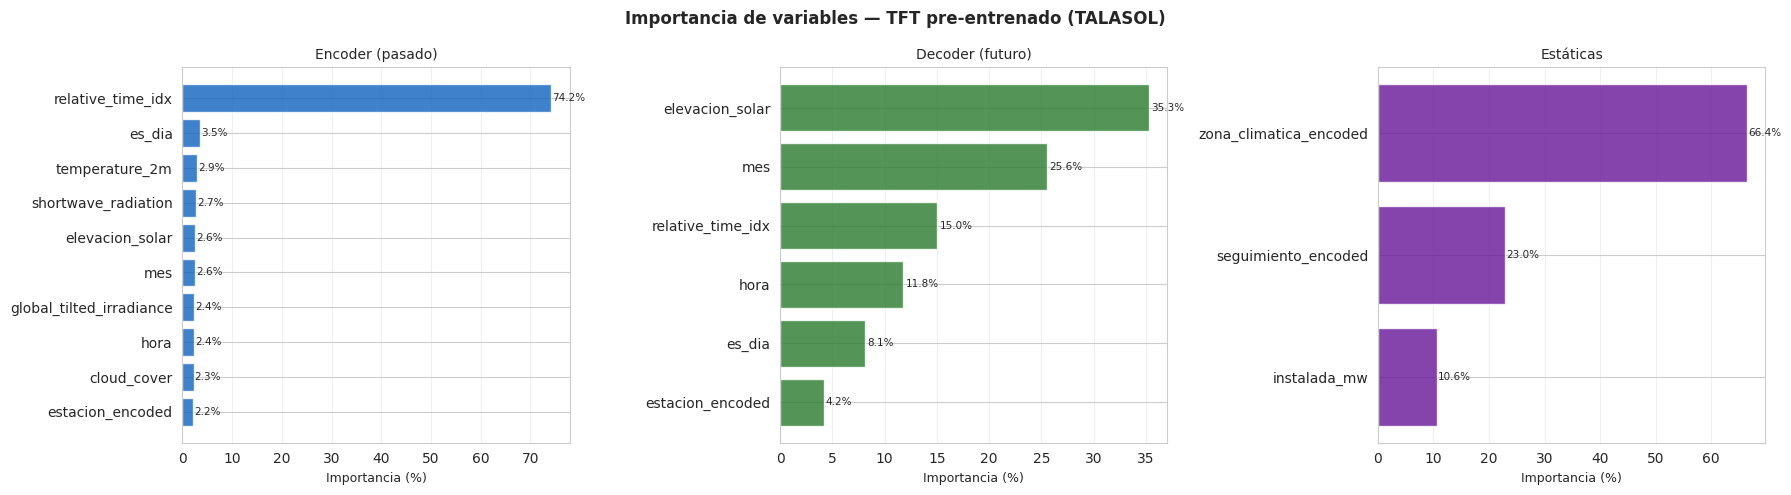

  Guardado: tft_var_importance_pretrained.png


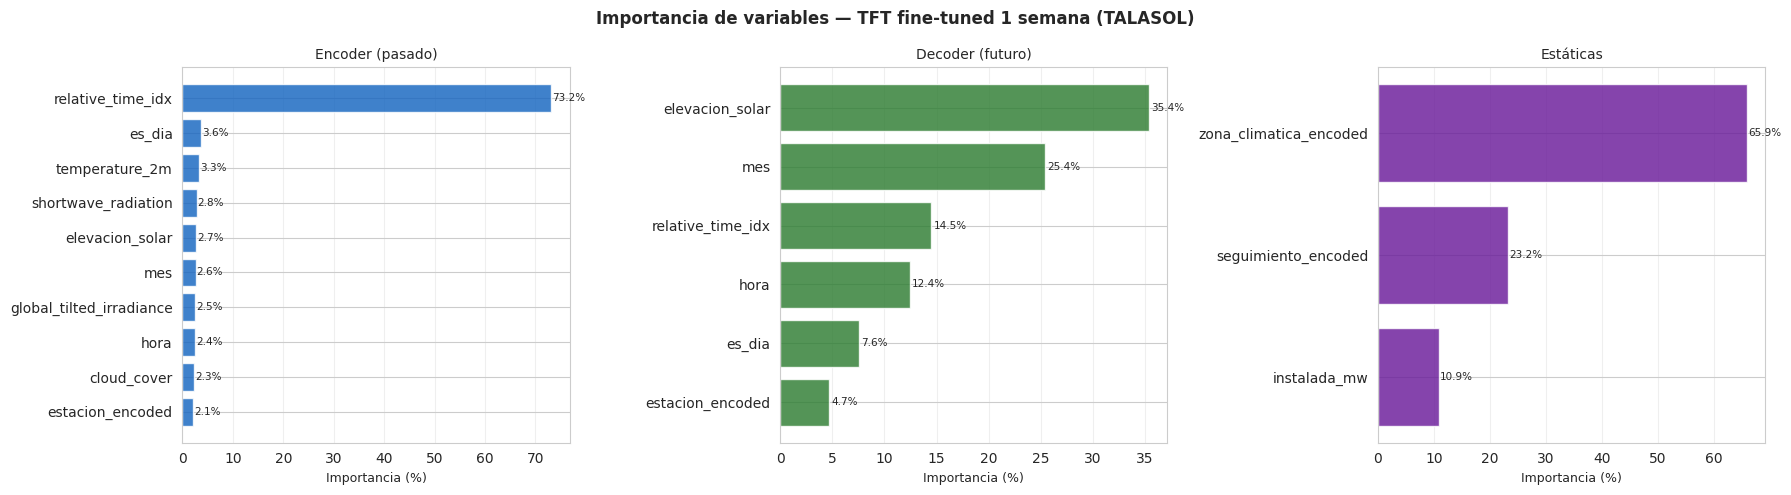

  Guardado: tft_var_importance_finetuned.png


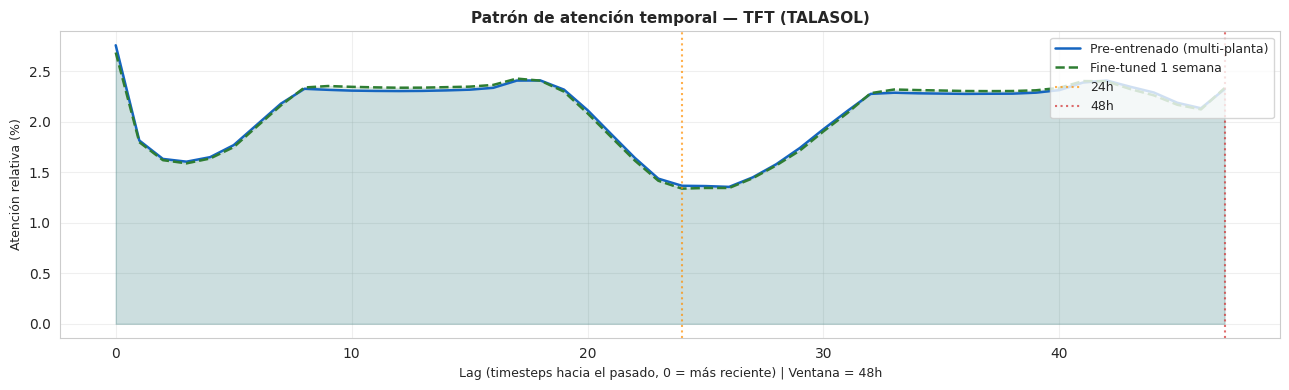

  Guardado: tft_attention_temporal.png

[Hallazgos 5.3.3]
  Lag con máxima atención : 0h hacia el pasado
  Atención en últimas 24h : 50.4%
  Top-3 encoder           : ['relative_time_idx', 'es_dia', 'temperature_2m']

5.3.3 OK


In [13]:

# ============================================================================
# 5.3.3. ANÁLISIS DE ATTENTION WEIGHTS (TFT)
# ============================================================================
# Interpretabilidad del TFT: qué variables y timesteps pasados son más
# relevantes para la predicción. Se carga el modelo pre-entrenado desde
# checkpoint para evitar reentrenamiento.
#
# Requiere: haber ejecutado las celdas 0 (setup) y 1 (datos).
# Outputs:
#   - Importancia de variables encoder, decoder y estáticas
#   - Patrón de atención temporal (distribución sobre el pasado)

print('5.3.3. Análisis de attention weights TFT')
print('=' * 80)

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

fig_dir = RESULTS_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

ckpt_pre = CHECKPOINTS_DIR / 'pretrained.ckpt'
ckpt_ft  = CHECKPOINTS_DIR / 'ft_1_semana.ckpt'

if not ckpt_pre.exists():
    raise FileNotFoundError(
        f'Checkpoint no encontrado: {ckpt_pre}\n'
        'Ejecuta primero la celda de pretraining (celda 2).'
    )

# ── A. Dataset de test de TALASOL ────────────────────────────────────────────
_, _, test_ds_i = build_target_datasets(
    planta_target      = PLANTA_TARGET,
    df_train           = df_train,
    df_val             = df_val,
    df_test            = df_test,
    known_reals        = TIME_VARYING_KNOWN_REALS,
    unknown_reals      = TIME_VARYING_UNKNOWN_REALS,
    static_reals       = STATIC_REALS,
    max_encoder_length = MAX_ENCODER_LENGTH,
    n_finetune_hours   = 0,
    smoke_test         = SMOKE_TEST,
    max_rows           = SMOKE_MAX_ROWS,
)
test_dl_i = test_ds_i.to_dataloader(
    train=False, batch_size=MODEL_CFG['batch_size'] * 2, num_workers=0, pin_memory=False
)
print(f'Dataset test TALASOL: {len(test_ds_i):,} secuencias')

# Nombres de variables — compatibles con pytorch-forecasting 0.10.x y >=1.x
if hasattr(test_ds_i, 'time_varying_reals_encoder'):
    enc_names  = list(test_ds_i.time_varying_reals_encoder)
    dec_names  = list(test_ds_i.time_varying_reals_decoder)
    stat_names = list(test_ds_i.static_reals)
else:
    _kn  = list(getattr(test_ds_i, 'time_varying_known_reals',
                         TIME_VARYING_KNOWN_REALS))
    _unk = list(getattr(test_ds_i, 'time_varying_unknown_reals',
                         TIME_VARYING_UNKNOWN_REALS + ['produccion']))
    stat_names = list(getattr(test_ds_i, 'static_reals', STATIC_REALS))
    _extra_enc, _extra_dec = [], []
    if getattr(test_ds_i, 'add_relative_time_idx', False):
        _extra_enc.append('relative_time_idx')
        _extra_dec.append('relative_time_idx')
    if getattr(test_ds_i, 'add_encoder_length', False):
        _extra_enc.append('encoder_length')
    if getattr(test_ds_i, 'add_target_scales', False):
        _extra_enc += ['target_scale_0', 'target_scale_1']
    enc_names = _kn + _unk + _extra_enc
    dec_names = _kn + _extra_dec

print(f'  Encoder vars ({len(enc_names)}): {enc_names}')
print(f'  Decoder vars ({len(dec_names)}): {dec_names}')
print(f'  Static  vars ({len(stat_names)}): {stat_names}')

# ── B. Cargar modelos desde checkpoint ───────────────────────────────────────
def _load_tft_from_ckpt(ckpt_path, ref_ds):
    # weights_only=False necesario porque el checkpoint contiene clases de
    # pytorch-forecasting (EncoderNormalizer) no incluidas en la allowlist
    # por defecto de PyTorch 2.6+. Los checkpoints son propios → seguro.
    ckpt  = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
    model = TemporalFusionTransformer.from_dataset(
        ref_ds,
        hidden_size                = MODEL_CFG['hidden_size'],
        lstm_layers                = 1,
        attention_head_size        = MODEL_CFG['attention_head_size'],
        dropout                    = MODEL_CFG['dropout'],
        hidden_continuous_size     = MODEL_CFG['hidden_continuous_size'],
        loss                       = QuantileLoss(quantiles=[0.5]),
        learning_rate              = MODEL_CFG['lr'],
        reduce_on_plateau_patience = 3,
        log_interval               = -1,
        log_val_interval           = -1,
    )
    missing, _ = model.load_state_dict(ckpt['state_dict'], strict=False)
    if missing:
        print(f'  ⚠ {len(missing)} keys no cargadas')
    model.eval()
    return model


print(f'\nCargando: {ckpt_pre.name}')
model_pre  = _load_tft_from_ckpt(ckpt_pre, test_ds_i)
print('  OK')

model_ft_i = None
if ckpt_ft.exists():
    print(f'Cargando: {ckpt_ft.name}')
    model_ft_i = _load_tft_from_ckpt(ckpt_ft, test_ds_i)
    print('  OK')
print(f'Modelo fine-tuned disponible: {model_ft_i is not None}')

# ── C. Obtener interpretación: forward manual por batch ───────────────────────
# predict(mode='raw') de pytorch-forecasting devuelve (predicciones_tensor, x)
# en 0.10.x, no el output completo que interpret_output necesita.
# Solución: model(x_batch) → forward completo → interpret_output por batch,
# luego sumar acumulativamente (equivale a reduction='sum' sobre todo el dataset).
def _get_interpretation(model, dataloader):
    model.eval()
    accumulated = {}
    n_batches   = 0

    with torch.no_grad():
        for x_b, _ in dataloader:
            out_b    = model(x_b)
            interp_b = model.interpret_output(out_b, reduction='sum')
            for key, val in interp_b.items():
                if isinstance(val, torch.Tensor):
                    accumulated[key] = accumulated.get(key, 0) + val
            n_batches += 1

    print(f'  Batches procesados: {n_batches}')
    return accumulated


print('\nCalculando interpretación del modelo pre-entrenado...')
interp_pre = _get_interpretation(model_pre, test_dl_i)

interp_ft = None
if model_ft_i is not None:
    print('Calculando interpretación del modelo fine-tuned...')
    interp_ft = _get_interpretation(model_ft_i, test_dl_i)

print(f'Keys disponibles: {list(interp_pre.keys())}')

# ── D. Importancia de variables ───────────────────────────────────────────────
def _plot_var_importance(interp, ax_list):
    keys_colors = [
        ('encoder_variables', enc_names, '#1565C0', 'Encoder (pasado)'),
        ('decoder_variables', dec_names, '#2E7D32', 'Decoder (futuro)'),
        ('static_variables',  stat_names, '#6A1B9A', 'Estáticas'),
    ]
    for ax, (key, names, color, label) in zip(ax_list, keys_colors):
        if key not in interp:
            ax.set_visible(False)
            continue
        imp = interp[key].cpu().numpy()
        n   = min(len(imp), len(names))
        imp_n, names_n = imp[:n], names[:n]
        total   = imp_n.sum()
        imp_pct = imp_n / total * 100 if total > 0 else imp_n
        top_idx = np.argsort(imp_pct)[::-1][:10]
        y_names = [names_n[i] for i in top_idx]
        y_vals  = [imp_pct[i] for i in top_idx]
        bars = ax.barh(y_names[::-1], y_vals[::-1], color=color, alpha=0.82)
        for bar, val in zip(bars, y_vals[::-1]):
            ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', va='center', fontsize=7.5)
        ax.set_xlabel('Importancia (%)', fontsize=9)
        ax.set_title(label, fontsize=10)
        ax.grid(axis='x', alpha=0.3)

n_groups = 3
fig_imp, axes_imp = plt.subplots(1, n_groups, figsize=(18, 5))
_plot_var_importance(interp_pre, axes_imp)
plt.suptitle(f'Importancia de variables — TFT pre-entrenado ({PLANTA_TARGET})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'tft_var_importance_pretrained.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: tft_var_importance_pretrained.png')

if interp_ft is not None:
    fig_imp2, axes_imp2 = plt.subplots(1, n_groups, figsize=(18, 5))
    _plot_var_importance(interp_ft, axes_imp2)
    plt.suptitle(f'Importancia de variables — TFT fine-tuned 1 semana ({PLANTA_TARGET})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'tft_var_importance_finetuned.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Guardado: tft_var_importance_finetuned.png')

# ── E. Patrón de atención temporal ────────────────────────────────────────────
if 'attention' in interp_pre:
    fig_attn, ax_attn = plt.subplots(figsize=(13, 4))
    to_compare = [('Pre-entrenado (multi-planta)', interp_pre, '#1565C0', '-')]
    if interp_ft is not None and 'attention' in interp_ft:
        to_compare.append(('Fine-tuned 1 semana', interp_ft, '#2E7D32', '--'))

    for label, interp, color, ls in to_compare:
        attn     = interp['attention'].cpu().numpy()
        lags     = np.arange(len(attn))
        attn_pct = attn / (attn.sum() + 1e-10) * 100
        ax_attn.plot(lags, attn_pct, ls=ls, lw=1.8, color=color, label=label)
        ax_attn.fill_between(lags, attn_pct, alpha=0.12, color=color)

    ax_attn.set_xlabel(f'Lag (timesteps hacia el pasado, 0 = más reciente) | '
                       f'Ventana = {MAX_ENCODER_LENGTH}h', fontsize=9)
    ax_attn.set_ylabel('Atención relativa (%)', fontsize=9)
    ax_attn.set_title(f'Patrón de atención temporal — TFT ({PLANTA_TARGET})',
                      fontsize=11, fontweight='bold')
    for ref_h, col, lab in [(24, '#FF8F00', '24h'),
                             (MAX_ENCODER_LENGTH - 1, '#D32F2F', f'{MAX_ENCODER_LENGTH}h')]:
        if ref_h < len(attn):
            ax_attn.axvline(x=ref_h, color=col, ls=':', alpha=0.7, label=lab)
    ax_attn.legend(fontsize=9, loc='upper right')
    ax_attn.grid(alpha=0.3)
    plt.tight_layout()
    fig_attn.savefig(fig_dir / 'tft_attention_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Guardado: tft_attention_temporal.png')

    attn_arr = interp_pre['attention'].cpu().numpy()
    lag_max  = int(np.argmax(attn_arr))
    pct_24h  = attn_arr[:min(24, len(attn_arr))].sum() / (attn_arr.sum() + 1e-10) * 100
    print(f'\n[Hallazgos 5.3.3]')
    print(f'  Lag con máxima atención : {lag_max}h hacia el pasado')
    print(f'  Atención en últimas 24h : {pct_24h:.1f}%')
    if 'encoder_variables' in interp_pre:
        enc_imp = interp_pre['encoder_variables'].cpu().numpy()
        n_enc   = min(len(enc_imp), len(enc_names))
        top3    = np.argsort(enc_imp[:n_enc])[::-1][:3]
        print(f'  Top-3 encoder           : {[enc_names[i] for i in top3]}')

print('\n5.3.3 OK')


5.3.4. Análisis de similaridad entre plantas
Features meteorológicas usadas: ['shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover', 'temperature_2m']

Features por planta (14 variables):
               instalada_mw  zona_climatica_encoded  seguimiento_encoded  shortwave_radiation_mean  direct_normal_irradiance_mean  global_tilted_irradiance_mean  cloud_cover_mean  temperature_2m_mean  shortwave_radiation_std  direct_normal_irradiance_std  global_tilted_irradiance_std  cloud_cover_std  temperature_2m_std  capacity_factor
planta_nombre                                                                                                                                                                                                                                                                                                                                     
UPGARNACHA         149.0000                  0.0000               1.0000                  221.2

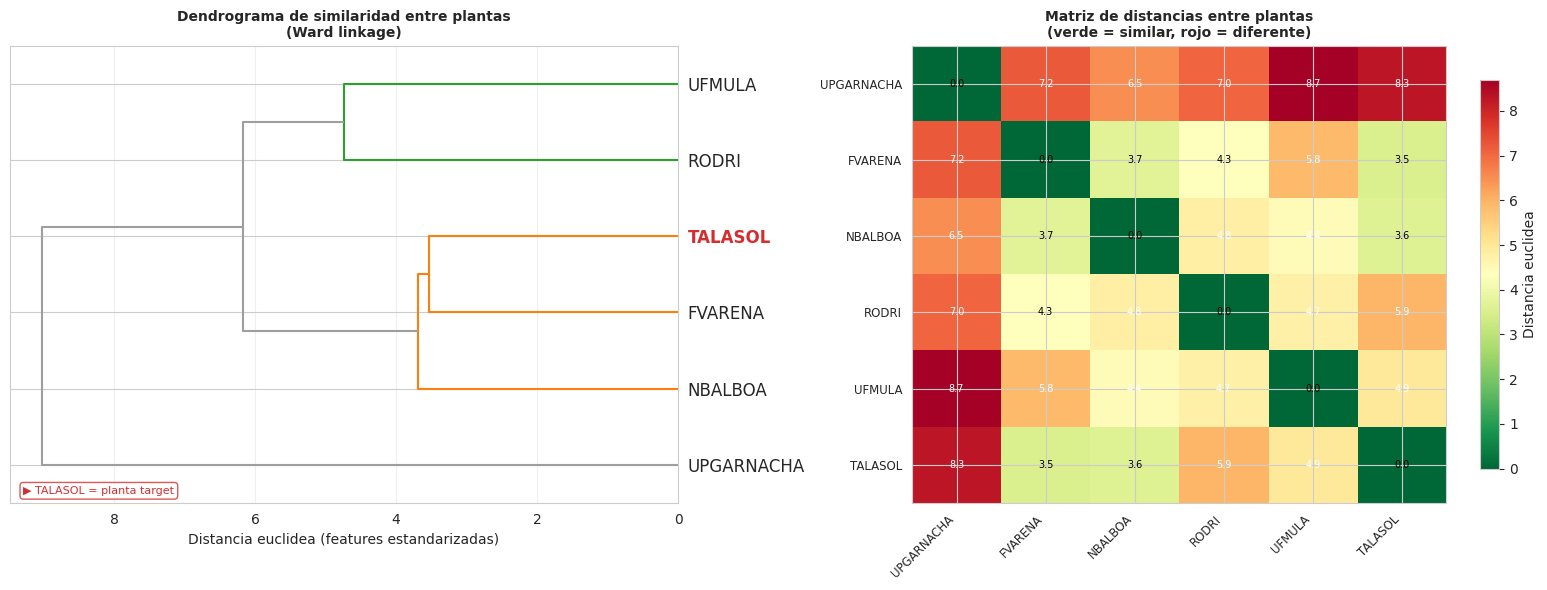


  Guardado: plant_similarity.png


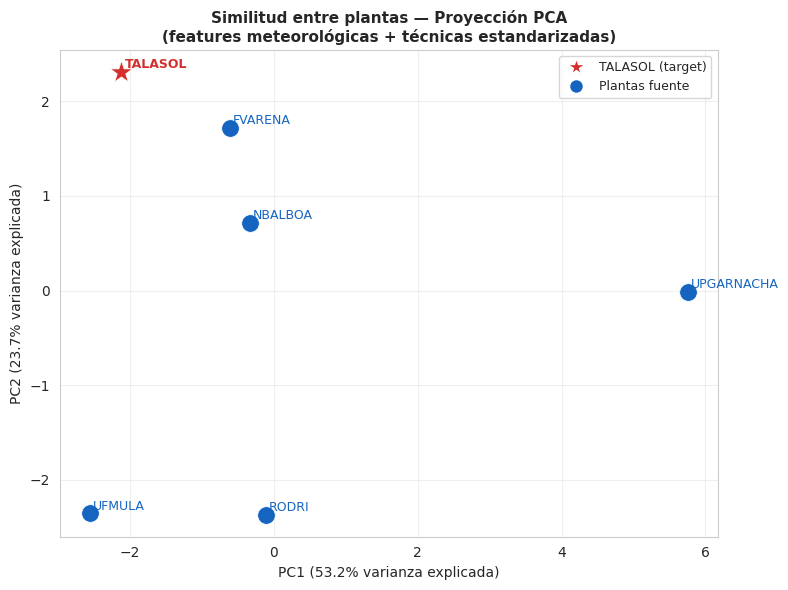

  Guardado: plant_similarity_pca.png

[Correlación con rendimiento de transferencia]
  Zero-shot MAE (sin datos TALASOL): 30.891
  Baseline MAE (TALASOL completo)  : 24.998

  Plantas más similares a TALASOL (candidatas a mejor zero-shot):
    1. FVARENA         dist=3.53  zona=Centro
    2. NBALBOA         dist=3.62  zona=Centro
    3. UFMULA          dist=4.95  zona=Sur

  Zona climática TALASOL: Centro
  → plantas de la misma zona deberían transferir mejor
  → mayor distancia → peor rendimiento esperado en zero-shot

5.3.4 OK


In [14]:

# ============================================================================
# 5.3.4. ANÁLISIS DE SIMILARIDAD ENTRE PLANTAS
# ============================================================================
# Clustering jerárquico basado en features meteorológicas y técnicas de cada
# planta. Objetivo: explicar los resultados de transferibilidad del Exp. 2
# (qué plantas transfieren mejor a TALASOL y por qué).
#
# Requiere: haber ejecutado las celdas 0 (setup) y 1 (datos).
# Outputs:
#   - Dendrograma de similaridad entre plantas
#   - Mapa de distancias entre todas las plantas
#   - Proyección PCA en 2D
#   - Correlación de similitud con rendimiento de transferencia

print('5.3.4. Análisis de similaridad entre plantas')
print('=' * 80)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import pdist, squareform
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from matplotlib.lines        import Line2D

todas_plantas = PLANTAS_SOURCE + [PLANTA_TARGET]

# ── A. Features estáticas por planta ─────────────────────────────────────────
static_cols = ['instalada_mw', 'zona_climatica_encoded', 'seguimiento_encoded']
static_feats = (
    df_train
    .groupby('planta_nombre')[static_cols]
    .first()
    .reindex(todas_plantas)
)

# ── B. Features meteorológicas agregadas ─────────────────────────────────────
meteo_cols = [c for c in TIME_VARYING_UNKNOWN_REALS if c in df_train.columns]
print(f'Features meteorológicas usadas: {meteo_cols}')

meteo_mean = (
    df_train[df_train['planta_nombre'].isin(todas_plantas)]
    .groupby('planta_nombre')[meteo_cols]
    .mean()
    .reindex(todas_plantas)
    .add_suffix('_mean')
)
meteo_std = (
    df_train[df_train['planta_nombre'].isin(todas_plantas)]
    .groupby('planta_nombre')[meteo_cols]
    .std()
    .reindex(todas_plantas)
    .add_suffix('_std')
)

# Factor de capacidad (producción media / potencia instalada)
prod_mean = (
    df_train[df_train['planta_nombre'].isin(todas_plantas)]
    .groupby('planta_nombre')['produccion']
    .mean()
    .reindex(todas_plantas)
)
cap_kw = static_feats['instalada_mw'] * 1000
cf = (prod_mean / (cap_kw + 1e-6)).rename('capacity_factor')

# Matriz de features completa
df_feat = pd.concat([static_feats, meteo_mean, meteo_std, cf], axis=1).fillna(0)

print(f'\nFeatures por planta ({len(df_feat.columns)} variables):')
print(df_feat.round(3).to_string())

# ── C. Normalización y clustering jerárquico ──────────────────────────────────
scaler   = StandardScaler()
X        = scaler.fit_transform(df_feat.values)
labels   = df_feat.index.tolist()

dist_vec = pdist(X, metric='euclidean')
linked   = linkage(dist_vec, method='ward')
dist_sq  = squareform(dist_vec)
df_dist  = pd.DataFrame(dist_sq, index=labels, columns=labels)

print(f'\nDistancias euclídeas a {PLANTA_TARGET}:')
dist_to_target = df_dist[PLANTA_TARGET].drop(PLANTA_TARGET).sort_values()
for planta, d in dist_to_target.items():
    print(f'  {planta:<15} : {d:.3f}')
print(f'  (menor distancia → mayor similaridad → mejor transferencia esperada)')

# ── D. Dendrograma + mapa de distancias ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrograma
ax_dend = axes[0]
dend = dendrogram(
    linked,
    labels            = labels,
    orientation       = 'left',
    ax                = ax_dend,
    color_threshold   = 0.65 * linked[-1, 2],
    above_threshold_color = '#9E9E9E',
)
# Colorear etiqueta del target en rojo (orientation='left' → etiquetas en eje y)
for lbl in ax_dend.get_yticklabels():
    if lbl.get_text() == PLANTA_TARGET:
        lbl.set_color('#D32F2F')
        lbl.set_fontweight('bold')

ax_dend.set_title(
    f'Dendrograma de similaridad entre plantas\n(Ward linkage)',
    fontsize=10, fontweight='bold')
ax_dend.set_xlabel('Distancia euclidea (features estandarizadas)')
ax_dend.grid(axis='x', alpha=0.3)

# Leyenda manual
ax_dend.annotate(
    f'▶ {PLANTA_TARGET} = planta target',
    xy=(0.02, 0.02), xycoords='axes fraction',
    fontsize=8, color='#D32F2F',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D32F2F', alpha=0.8)
)

# Mapa de distancias
ax_heat = axes[1]
n = len(labels)
im = ax_heat.imshow(df_dist.values, cmap='RdYlGn_r', aspect='auto',
                    vmin=0, vmax=df_dist.values.max())
plt.colorbar(im, ax=ax_heat, label='Distancia euclidea', shrink=0.85)

ax_heat.set_xticks(range(n))
ax_heat.set_yticks(range(n))
ax_heat.set_xticklabels(labels, rotation=45, ha='right', fontsize=8.5)
ax_heat.set_yticklabels(labels, fontsize=8.5)
ax_heat.set_title(
    'Matriz de distancias entre plantas\n(verde = similar, rojo = diferente)',
    fontsize=10, fontweight='bold')

for i in range(n):
    for j in range(n):
        ax_heat.text(j, i, f'{df_dist.iloc[i, j]:.1f}',
                     ha='center', va='center', fontsize=7,
                     color='white' if df_dist.iloc[i, j] > df_dist.values.max() * 0.5
                     else 'black')

plt.tight_layout()
plt.savefig(fig_dir / 'plant_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Guardado: plant_similarity.png')

# ── E. Proyección PCA 2D ──────────────────────────────────────────────────────
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

fig_pca, ax_pca = plt.subplots(figsize=(8, 6))

for planta, x_p in zip(labels, X_pca):
    is_target = (planta == PLANTA_TARGET)
    color  = '#D32F2F' if is_target else '#1565C0'
    marker = '*'       if is_target else 'o'
    size   = 280       if is_target else 160
    ax_pca.scatter(x_p[0], x_p[1], c=color, s=size, marker=marker,
                   zorder=3, edgecolors='white', linewidths=0.5)
    offset = (0.06, 0.04) if is_target else (0.04, 0.04)
    ax_pca.annotate(planta, (x_p[0] + offset[0], x_p[1] + offset[1]),
                    fontsize=9, color=color,
                    fontweight='bold' if is_target else 'normal')

ax_pca.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza explicada)', fontsize=10)
ax_pca.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza explicada)', fontsize=10)
ax_pca.set_title('Similitud entre plantas — Proyección PCA\n'
                 '(features meteorológicas + técnicas estandarizadas)',
                 fontsize=11, fontweight='bold')

legend_els = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#D32F2F',
           markersize=13, label=f'{PLANTA_TARGET} (target)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1565C0',
           markersize=10, label='Plantas fuente'),
]
ax_pca.legend(handles=legend_els, fontsize=9)
ax_pca.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'plant_similarity_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: plant_similarity_pca.png')

# ── F. Relación con resultados de transferencia ────────────────────────────────
results_csv = RESULTS_DIR / 'metrics.csv'
print(f'\n[Correlación con rendimiento de transferencia]')
if results_csv.exists():
    df_res = pd.read_csv(results_csv)
    df_latest_res = df_res.sort_values('timestamp').groupby('scenario').last()
    if 'zero_shot' in df_latest_res.index:
        mae_zs = df_latest_res.loc['zero_shot', 'MAE']
        print(f'  Zero-shot MAE (sin datos TALASOL): {mae_zs:.3f}')
    if 'baseline' in df_latest_res.index:
        mae_bl = df_latest_res.loc['baseline', 'MAE']
        print(f'  Baseline MAE (TALASOL completo)  : {mae_bl:.3f}')
else:
    print('  metrics.csv no encontrado — ejecuta las celdas de entrenamiento primero')

print(f'\n  Plantas más similares a {PLANTA_TARGET} (candidatas a mejor zero-shot):')
for i, (p, d) in enumerate(dist_to_target.head(3).items()):
    zona = df_train[df_train['planta_nombre'] == p]['zona_climatica'].iloc[0] \
           if len(df_train[df_train['planta_nombre'] == p]) > 0 else '?'
    print(f'    {i+1}. {p:<15} dist={d:.2f}  zona={zona}')

zona_target = df_train[df_train['planta_nombre'] == PLANTA_TARGET]['zona_climatica'].iloc[0] \
              if len(df_train[df_train['planta_nombre'] == PLANTA_TARGET]) > 0 else '?'
print(f'\n  Zona climática {PLANTA_TARGET}: {zona_target}')
print(f'  → plantas de la misma zona deberían transferir mejor')
print(f'  → mayor distancia → peor rendimiento esperado en zero-shot')

print('\n5.3.4 OK')
